<a href="https://colab.research.google.com/github/plopezmp/AmI/blob/main/c2021_Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Distribución Gaussiana

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import math
from scipy.stats import multivariate_normal
from mpl_toolkits.mplot3d import Axes3D

$$ 
  p(x; \mu,\sigma)= \frac{1}{\sigma\sqrt{2 \pi}} \exp\left({-\frac{(x-\mu)^2}{2\sigma^2}}\right)
$$

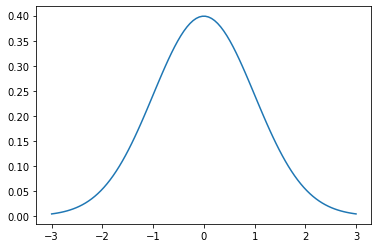

In [2]:
mu = 0
variance = 1
sigma = math.sqrt(variance)
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma))
plt.show()

In [3]:
def gaussian(x, mu, sig):
    return np.exp(-np.power(x - mu, 2.) / (2 * np.power(sig, 2.)))

In [4]:
x_values = np.linspace(-3, 3, 120)

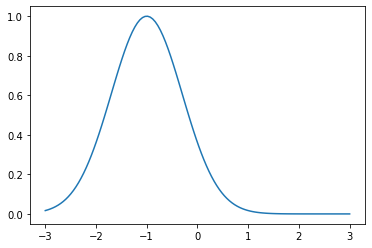

In [67]:
plt.plot(x_values, gaussian(x_values,-1,0.7))
plt.show()

# Distribución Gaussiana multivariable

La matriz de covarianza debe ser simétrica y definida positiva, es decir determinante $\neq 0$.
The probability density function for `multivariate_normal` is
.. math:

$$
        p(x;\mu,\Sigma) = \frac{1}{(2 \pi)^{n/2} |\Sigma|^{1/2}}
               \exp\left( -\frac{1}{2} (x - \mu)^T \Sigma^{-1} (x - \mu)\right),
$$

donde $\mu \in \mathbb{R}^n$ y $\Sigma \in \mathbb{R}^n \times \mathbb{R}^n$

## Ejemplos con 2 variables independientes

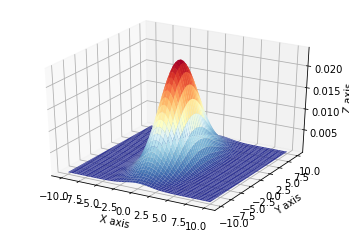

In [62]:
# Parámetros
mu_x = 0
variance_x = 3

mu_y = 0
variance_y = 15

# Crear grid 
x = np.linspace(-10,10,500)
y = np.linspace(-10,10,500)
X, Y = np.meshgrid(x,y)
pos = np.empty(X.shape + (2,))
pos[:, :, 0] = X; pos[:, :, 1] = Y
S = [[variance_x, 0], [0, variance_y]]
rv = multivariate_normal([mu_x, mu_y], S)

# 3D plot
fig = plt.figure()
ax = fig.gca(projection='3d')
ax.plot_surface(X, Y, rv.pdf(pos),cmap='RdYlBu_r',linewidth=0)
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')
plt.show()

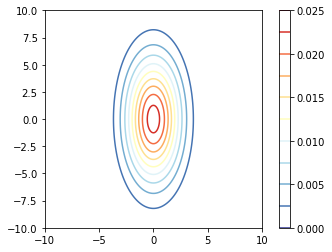

In [63]:
plt.contour(X, Y, rv.pdf(pos), 10, cmap='RdYlBu_r');
plt.colorbar();
plt.gca().set_aspect("equal")

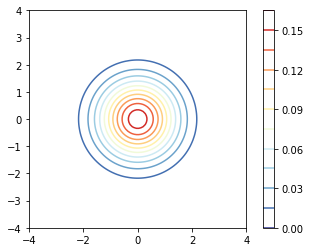

In [55]:
mu_x = 0
variance_x = 1

mu_y = 0
variance_y = 1

mu = [mu_x,mu_y]
S= [[variance_x, 0], [0, variance_y]]
x = np.linspace(-4,4,100)
y = np.linspace(-4,4,100)
X, Y = np.meshgrid(x,y)
pos = np.empty(X.shape + (2,))
pos[:, :, 0] = X; pos[:, :, 1] = Y
Z = multivariate_normal(mu, S)
plt.contour(X, Y, Z.pdf(pos), 10, cmap='RdYlBu_r');
plt.colorbar();
plt.gca().set_aspect("equal")

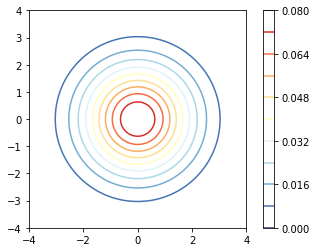

In [57]:
mu_x = 0
variance_x = 2

mu_y = 0
variance_y = 2

mu = [mu_x,mu_y]
S= [[variance_x, 0], [0, variance_y]]
x = np.linspace(-4,4,100)
y = np.linspace(-4,4,100)
X, Y = np.meshgrid(x,y)
pos = np.empty(X.shape + (2,))
pos[:, :, 0] = X; pos[:, :, 1] = Y
Z = multivariate_normal(mu, S)
plt.contour(X, Y, Z.pdf(pos), 10, cmap='RdYlBu_r');
plt.colorbar();
plt.gca().set_aspect("equal")

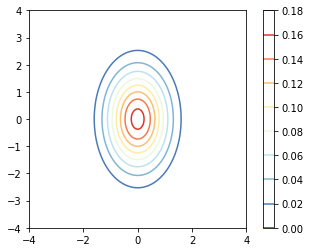

In [58]:
mu_x = 0
variance_x = 0.6
mu_y = 0
variance_y = 1.5
mu = [mu_x,mu_y]
S= [[variance_x, 0], [0, variance_y]]
x = np.linspace(-4,4,100)
y = np.linspace(-4,4,100)
X, Y = np.meshgrid(x,y)
pos = np.empty(X.shape + (2,))
pos[:, :, 0] = X; pos[:, :, 1] = Y
Z = multivariate_normal(mu, S)
plt.contour(X, Y, Z.pdf(pos), 10, cmap='RdYlBu_r');
plt.colorbar();
plt.gca().set_aspect("equal")

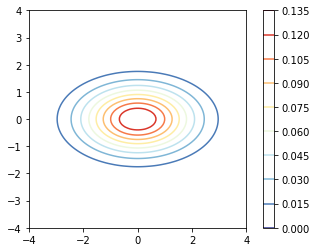

In [60]:
mu_x = 0
variance_x = 2
mu_y = 0
variance_y = 0.7
mu = [mu_x,mu_y]
S= [[variance_x, 0], [0, variance_y]]
x = np.linspace(-4,4,100)
y = np.linspace(-4,4,100)
X, Y = np.meshgrid(x,y)
pos = np.empty(X.shape + (2,))
pos[:, :, 0] = X; pos[:, :, 1] = Y
Z = multivariate_normal(mu, S)
plt.contour(X, Y, Z.pdf(pos), 10, cmap='RdYlBu_r');
plt.colorbar();
plt.gca().set_aspect("equal")

## Correlación entre las dos variables

Por ejemplo:
$$
  \Sigma= 
  \begin{bmatrix}
    1 & 0.5  \\
    0.5 & 1 
  \end{bmatrix}
$$

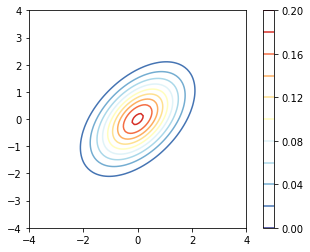

In [6]:
mu_x = 0
variance_x = 1
mu_y = 0
variance_y = 1
mu = [mu_x,mu_y]
# La correlación x1 y x2 es 0.5 -> "NOTA: probar 0.85 y -0.85"
S= [[variance_x, 0.5], [0.5, variance_y]]
x = np.linspace(-4,4,100)
y = np.linspace(-4,4,100)
X, Y = np.meshgrid(x,y)
pos = np.empty(X.shape + (2,))
pos[:, :, 0] = X; pos[:, :, 1] = Y
Z = multivariate_normal(mu, S)
plt.contour(X, Y, Z.pdf(pos), 10, cmap='RdYlBu_r');
plt.colorbar();
plt.gca().set_aspect("equal")

Lógicamente, si cambiamos el valor de $\mu$, el pico de la Gaussiana cambia a ese valor (por ejemplo, probar $\mu_1=-1,\mu_2=1$)

# Transformación de *features*

Transformar features para que parezcan más una pdf Gaussiana

Mirar el siguiente enlace:
[``Transforming Non-Normal Distribution to Normal Distribution''](https://aegis4048.github.io/transforming-non-normal-distribution-to-normal-distribution)

El enlace contiene ejemplos de la técnica de transformación "Box-Cox".

In [3]:
# sample data generation
np.random.seed(42)
data = sorted(stats.lognorm.rvs(s=0.5, loc=1, scale=1000, size=1000))

# fit lognormal distribution
shape, loc, scale = stats.lognorm.fit(data, loc=0)
pdf_lognorm = stats.lognorm.pdf(data, shape, loc, scale)

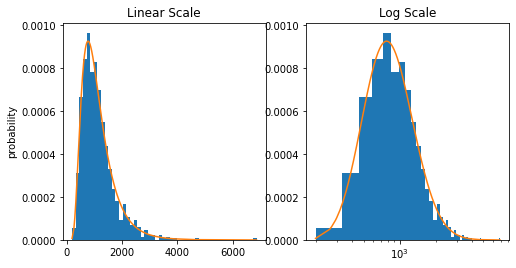

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

ax1.hist(data, bins='auto', density=True)
ax1.plot(data, pdf_lognorm)
ax1.set_ylabel('probability')
ax1.set_title('Linear Scale')

ax2.hist(data, bins='auto', density=True)
ax2.plot(data, pdf_lognorm)
ax2.set_xscale('log')
ax2.set_title('Log Scale');